# A1 Deconvolution Analysis

This notebook performs comprehensive hallucination analysis on deconvolution models using the CANDELS dataset.
It combines the data loading from `frequency_class_analysis_CANDELS.ipynb` with the extensive analysis structure from `N1_Denoising.ipynb`.

**Models analyzed:**
- U-Net (L1 and L2 loss)
- SUNet (L1 and L2 loss)
- LearnLet (L1 and L2 loss)
- DRUNet PnP (from deepinv)

**Analysis performed:**
- Wavelet-based CHEM (HI) computation
- Level-wise frequency class analysis
- MSE and R-value spatial maps
- Model comparison across multiple metrics

## 1. Setup and Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import sys
import torch
import yaml
from collections import OrderedDict
from glob import glob
from PIL import Image
import pywt
import pickle
import pandas as pd

# DeepInv imports
import deepinv as dinv
from deepinv.utils import load_dataset, load_degradation

# Set up paths
project_root = Path('PATH/TO/FILE')
src_dir = project_root / 'src'
model_dir = src_dir / 'train' / 'model'


# Add necessary directories to path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(src_dir / 'train') not in sys.path:
    sys.path.insert(0, str(src_dir / 'train'))

# Import utilities
import utils
from src.utils.cqr2 import confidence_radius
from src.utils.io import load_paths
from src.utils.HIC_psf_fwhm_wavelet_utils import Wavelet_Hallucination_Index
from src.utils.HIC_psf_fwhm_base_utils import Hallucination_Index

# Load paths configuration
paths = load_paths()

# Set device
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
print(f'Using device: {device}')
print("Imports successful!")

## 2. Load CANDELS Dataset

In [2]:
print("Loading CANDELS test dataset...")
f = open(paths['data_file'], 'rb')
dico = pickle.load(f)
f.close()

# Extract data
y_test = dico['inputs_tikho_laplacian']  # Input images (blurred)
x_test = dico['targets']                 # Target images (ground truth)
noisy = dico['noisy']                    # Noisy images

print(f"Dataset loaded:")
print(f"  Inputs shape: {y_test.shape}")
print(f"  Targets shape: {x_test.shape}")
print(f"  Noisy shape: {noisy.shape}")
print(f"  Number of test images: {len(x_test)}")

Loading CANDELS test dataset...
Dataset loaded:
  Inputs shape: (2232, 128, 128)
  Targets shape: (2232, 128, 128)
  Noisy shape: (2232, 128, 128)
  Number of test images: 2232


## 3. Define Physics Operator (Deconvolution)

In [ ]:

print("Physics operator: Deconvolution (pre-applied in CANDELS dataset)")
print("  - Inputs: Blurred images (Tikhonov-Laplacian regularized)")
print("  - Targets: Sharp ground truth images")
print("  - Task: Recover sharp image from blurred observation")

filter = torch.ones((1, 1, 2, 2)) / 4 # Basic 2x2 filter
physics = dinv.physics.BlurFFT(
    img_size=(1, 128, 128),
    filter=filter,
    device=device,
    noise_model=dinv.physics.GaussianNoise(sigma=15),
)

Physics operator: Deconvolution (pre-applied in CANDELS dataset)
  - Inputs: Blurred images (Tikhonov-Laplacian regularized)
  - Targets: Sharp ground truth images
  - Task: Recover sharp image from blurred observation


## 4. Load Models

Loading custom trained models (UNet, SUNet, LearnLet) and DRUNet PnP from deepinv library.

In [ ]:
print("Loading models...")

models = {}

# Import all model architectures
from src.train.model.Unet import UNet
from src.train.model.SUNet import SUNet_model
from src.train.model.LearnLet import Learnlet

# Define model configurations for custom trained models
model_configs = {
    'U-Net_L1': (paths['configs_dir'] / 'training_UNet_L1.yaml', 'U-Net/L1_Loss', 'model_bestPSNR_ep-300_bs-4_ps-4.pth', 'unet'),
    'U-Net_L2': (paths['configs_dir'] / 'training_UNet_L2.yaml', 'U-Net/L2_Loss', 'model_bestPSNR_ep-300_bs-4_ps-4.pth', 'unet'),
    'SUNet_L1': (paths['configs_dir'] / 'training_SUNet_L1.yaml', 'SUNet/L1_Loss', 'model_bestPSNR_ep-300_bs-4_ps-4.pth', 'sunet'),
    'SUNet_L2': (paths['configs_dir'] / 'training_SUNet_L2.yaml', 'SUNet/L2_Loss', 'model_bestPSNR_ep-300_bs-4_ps-4.pth', 'sunet'),
    'LearnLet_L1': (paths['configs_dir'] / 'training_LeLet_L1.yaml', 'LearnLet/L1_Loss', 'model_bestPSNR_ep-300_bs-4_ps-4.pth', 'learnlet'),
    'LearnLet_L2': (paths['configs_dir'] / 'training_LeLet_L2.yaml', 'LearnLet/L2_Loss', 'model_bestPSNR_ep-300_bs-4_ps-4.pth', 'learnlet'),
}

# Helper function to load checkpoint
def load_checkpoint(model, weights, device):
    checkpoint = torch.load(weights, map_location=device)
    try:
        model.load_state_dict(checkpoint["state_dict"])
    except:
        state_dict = checkpoint["state_dict"]
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] if k.startswith('module.') else k
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)
    return model

# Load custom trained models
for model_name, (config_path, model_dir, weights_file, model_type) in model_configs.items():
    print(f"  Loading {model_name}...")
    
    # Load config
    with open(config_path, 'r') as f:
        opt = yaml.safe_load(f)
    
    # Model path
    full_model_dir = src_dir / 'models' / model_dir
    model_weights = full_model_dir / weights_file
    
    # Initialize appropriate model architecture
    if model_type == 'unet':
        model = UNet(1)  # Single channel (grayscale)
    elif model_type == 'sunet':
        model = SUNet_model(opt)  # Pass full config
    elif model_type == 'learnlet':
        model = Learnlet(n_scales=5, kernel_size=5, filters=64, exact_rec=True, thresh='hard')
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    model = load_checkpoint(model, model_weights, device)
    model.to(device)
    model.eval()
    
    models[model_name] = model
    print(f"    ✓ {model_name} loaded successfully")

# 2. DRUNet with PnP (Plug-and-Play)
print("  Loading DRUNet-PnP...")

# GSPnP prior setup
from deepinv.optim.data_fidelity import L2
from deepinv.optim.prior import RED, PnP
from deepinv.optim import PGD, DRS

class GSPnP(RED):
    """Gradient-Step Denoiser prior."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.explicit_prior = True

    def forward(self, x, *args, **kwargs):
        return self.denoiser.potential(x, *args, **kwargs)

# Parameters for PnP algorithm
lambda_reg = 1.0  # Regularization parameter
sigma_denoiser = 0.01  # Denoiser noise level
stepsize = 1.0
max_iter = 100

data_fidelity = L2()
prior = GSPnP(denoiser=dinv.models.GSDRUNet(pretrained="download").to(device))

def custom_output(X):
    return X["est"][1]

drunet_pnp = PGD(
    prior=prior,
    g_first=True,
    data_fidelity=data_fidelity,
    sigma_denoiser=sigma_denoiser,
    lambda_reg=lambda_reg,
    stepsize=stepsize,
    early_stop=True,
    max_iter=max_iter,
    crit_conv="cost",
    thres_conv=1e-5,
    backtracking=False,
    get_output=custom_output,
    verbose=False,
)
drunet_pnp.eval()

models['DRUNet-PnP'] = drunet_pnp
print("    ✓ DRUNet-PnP loaded")


print(f"\nTotal models loaded: {len(models)}")
for name in models.keys():
    print(f"  - {name}")

## 5. Visualize Sample Predictions

Generate predictions from all models on a sample image.

Evaluating models on sample image 0...
  U-Net_L1: PSNR = 20.39 dB
  U-Net_L2: PSNR = 20.38 dB
  SUNet_L1: PSNR = 20.42 dB
  SUNet_L2: PSNR = 20.31 dB
  LearnLet_L1: PSNR = 20.36 dB
  LearnLet_L2: PSNR = 20.36 dB
  DRUNet-PnP: PSNR = 17.02 dB


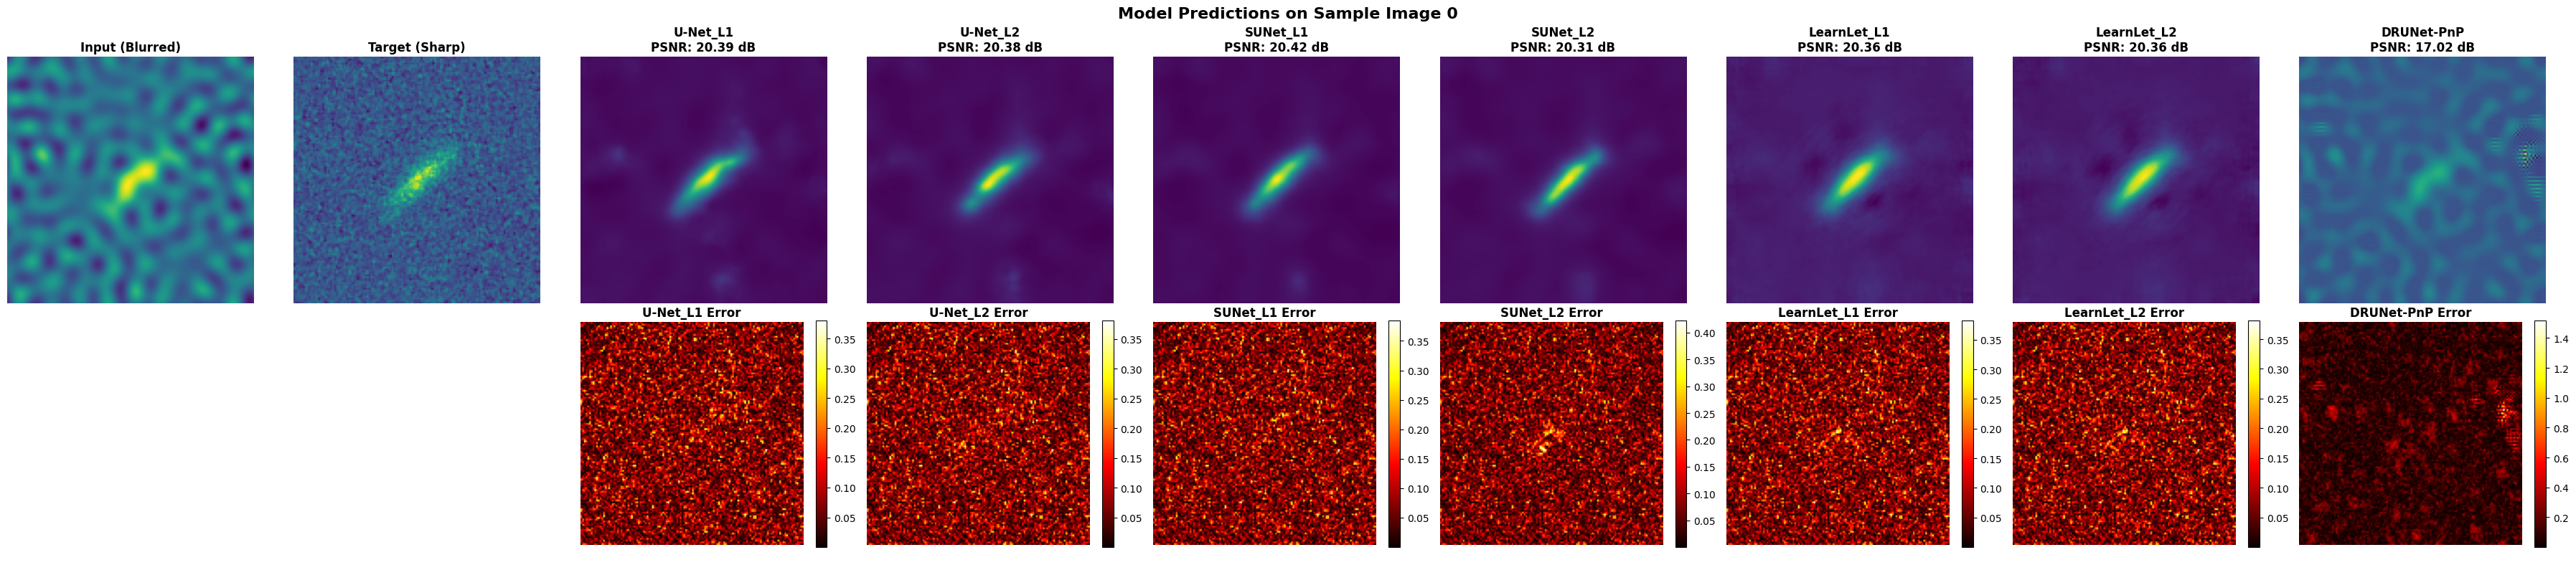


Sample predictions generated successfully!


In [5]:
# Select a sample image for visualization
sample_idx = 0

print(f"Evaluating models on sample image {sample_idx}...")

# Get sample data
sample_input = y_test[sample_idx]  # Shape: [H, W]
sample_target = x_test[sample_idx]  # Shape: [H, W]
sample_noisy = noisy[sample_idx]  # Shape: [H, W]

# Normalize (following CANDELS normalization convention)
x_norm = sample_target - np.mean(sample_target)
norm_fact = np.max(x_norm)
x_norm /= norm_fact

y_norm = sample_input - np.mean(sample_input)
y_norm /= norm_fact

# Convert to tensor format [1, 1, H, W]
y_tensor = torch.tensor(y_norm[np.newaxis, np.newaxis, :, :].astype(np.float32)).to(device)
x_tensor = torch.tensor(x_norm[np.newaxis, np.newaxis, :, :].astype(np.float32)).to(device)

# Generate predictions
predictions = {}
psnr_scores = {}
metric = dinv.metric.PSNR()


for name, model in models.items():
    with torch.no_grad():
        if name == 'DRUNet-PnP':
            # DRUNet expects RGB images (3 channels) - convert grayscale to 3-channel
            y_rgb = y_tensor.repeat(1, 3, 1, 1)  # [1, 1, H, W] -> [1, 3, H, W]
            pred_rgb = model(y_rgb, physics)
            # Convert back to grayscale by averaging channels
            pred = pred_rgb.mean(dim=1, keepdim=True)  # [1, 3, H, W] -> [1, 1, H, W]
        else:
            # Custom models work with grayscale directly
            pred = model(y_tensor)
        
        predictions[name] = pred
        psnr = metric(pred, x_tensor)
        psnr_scores[name] = psnr.item()
        print(f"  {name}: PSNR = {psnr.item():.2f} dB")

# Visualize predictions
n_models = len(models)
fig, axes = plt.subplots(2, n_models + 2, figsize=(4*(n_models+2), 8))

# Row 0: Input and Target
axes[0, 0].imshow(y_norm, cmap='viridis')
axes[0, 0].set_title('Input (Blurred)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(x_norm, cmap='viridis')
axes[0, 1].set_title('Target (Sharp)', fontweight='bold')
axes[0, 1].axis('off')

# Row 0: Model predictions
for idx, (name, pred) in enumerate(predictions.items()):
    pred_np = pred.cpu().numpy()[0, 0, :, :]
    axes[0, idx+2].imshow(pred_np, cmap='viridis')
    axes[0, idx+2].set_title(f'{name}\nPSNR: {psnr_scores[name]:.2f} dB', fontweight='bold')
    axes[0, idx+2].axis('off')

# Row 1: Error maps
axes[1, 0].axis('off')
axes[1, 1].axis('off')

for idx, (name, pred) in enumerate(predictions.items()):
    pred_np = pred.cpu().numpy()[0, 0, :, :]
    error_map = np.abs(pred_np - x_norm)
    im = axes[1, idx+2].imshow(error_map, cmap='hot')
    axes[1, idx+2].set_title(f'{name} Error', fontweight='bold')
    axes[1, idx+2].axis('off')
    plt.colorbar(im, ax=axes[1, idx+2], fraction=0.046)

plt.suptitle(f'Model Predictions on Sample Image {sample_idx}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSample predictions generated successfully!")

## 6. Prepare Calibration Data for Confidence Intervals

In [ ]:
print("Preparing calibration data for confidence interval computation...")

# Load calibration dataset
x_train = np.load(paths["x_train_file"])
y_train = np.load(paths["y_train_file"])

# Use subset for calibration 
x_cal = x_train[10000:10500, :, :, :]
y_cal = y_train[10000:10500, :, :, :]
del x_train, y_train

print(f"Calibration data loaded:")
print(f"  x_cal shape: {x_cal.shape}")
print(f"  y_cal shape: {y_cal.shape}")

# Normalize targets (same as test data)
x_cal = x_cal - np.mean(x_cal, axis=(1, 2), keepdims=True)
norm_fact = np.max(x_cal, axis=(1, 2), keepdims=True)
x_cal /= norm_fact

# Normalize inputs
y_cal = y_cal - np.mean(y_cal, axis=(1, 2), keepdims=True)
y_cal /= norm_fact

# Convert to NCHW convention
x_cal = np.moveaxis(x_cal, -1, 1)
y_cal = np.moveaxis(y_cal, -1, 1)

# Convert to torch tensor
x_cal = torch.tensor(x_cal).float()
y_cal = torch.tensor(y_cal).float()

# Split calibration data in half
n_obj = x_cal.size()[0]
n_cal0 = int(n_obj * 0.5)

y_cal0 = y_cal[0:n_cal0, :, :, :]
x_cal0 = x_cal[0:n_cal0, :, :, :]

y_cal1 = y_cal[n_cal0:, :, :, :]
x_cal1 = x_cal[n_cal0:, :, :, :]

print(f"\nCalibration data split:")
print(f"  Cal0: {y_cal0.shape[0]} samples")
print(f"  Cal1: {y_cal1.shape[0]} samples")
print("Calibration data prepared successfully!")

Preparing calibration data for confidence interval computation...
Calibration data loaded:
  x_cal shape: (500, 128, 128, 1)
  y_cal shape: (500, 128, 128, 1)

Calibration data split:
  Cal0: 250 samples
  Cal1: 250 samples
Calibration data prepared successfully!


## 7. Compute Confidence Intervals

In [ ]:
print("Computing confidence intervals for all models...")

alpha = 0.01  # Significance level
theta = 1     # Threshold parameter

confidence_intervals = {}

def patch_deepinv_typo():
    """Patch deepinv library typo: backtraking_config -> backtracking_config"""
    try:
        from deepinv.optim.optim_iterators import fStep, HQSIteration, ADMMIteration, PGDIteration
        
        # Ensure required attributes exist for FixedPoint iteration classes
        for iteration_class in [PGDIteration]:
            if hasattr(iteration_class, '__init__'):
                original_init = iteration_class.__init__
                
                def patched_init(self, *args, **kwargs):
                    original_init(self, *args, **kwargs)
                    # Add attribute if missing
                    if hasattr(self, 'backtracking_config') and not hasattr(self, 'backtraking_config'):
                        self.backtraking_config = self.backtracking_config
                
                iteration_class.__init__ = patched_init
        print("  ✓ Applied deepinv typo patch")
    except Exception as e:
        print(f"  ⚠ Could not apply patch: {e}")

patch_deepinv_typo()

# Create wrapper for DRUNet 
def model_wrapper(model, model_name, physics_op):
    """Wrapper to handle different model signatures for confidence interval computation"""
    class ModelWrapper:
        def __init__(self, model, name, physics):
            self.model = model
            self.name = name
            self.physics = physics
            
        def __call__(self, x):
            # Handle grayscale to RGB conversion for DRUNet
            if x.shape[1] == 1:
                x_rgb = x.repeat(1, 3, 1, 1)
            else:
                x_rgb = x
            
            output_rgb = self.model(x_rgb, physics=self.physics)
            
            # Convert back to grayscale
            if x.shape[1] == 1:
                output = output_rgb.mean(dim=1, keepdim=True)
            else:
                output = output_rgb
            
            return output
        
        def eval(self):
            self.model.eval()
            return self
        
        def to(self, device):
            self.model.to(device)
            return self
    
    return ModelWrapper(model, model_name, physics_op)

for model_name in models.keys():
    print(f"\n  Computing confidence interval for {model_name}...")
    
    if model_name == 'DRUNet-PnP':
        wrapped_model = model_wrapper(models[model_name],'DRUNet-PnP', physics_op = physics)
    else:
        wrapped_model = models[model_name]
    
    confidence_interval =confidence_radius(
        model=wrapped_model,
        input_cal0=y_cal0,
        label_cal0=x_cal0,
        input_cal1=y_cal1,
        label_cal1=x_cal1,
        alpha=alpha,
        device=device, 
        batch_size = 1
    )
        
    confidence_intervals[model_name] = confidence_interval
    print(f"    ✓ Confidence interval computed (shape: {confidence_interval.shape}, mean: {confidence_interval.mean():.6f})")
        

# Clean up memory
del x_cal, x_cal0, x_cal1, y_cal, y_cal0, y_cal1

print("\nConfidence interval computation complete!")

Computing confidence intervals for all models...
  ✓ Applied deepinv typo patch

  Computing confidence interval for U-Net_L1...

CONFIDENCE RADIUS COMPUTATION
Alpha: 0.01
Minimum calibration size required: 99
Cal0 size: 250 ✓
Cal1 size: 250 ✓

Batch size: 1

  Conformity score computation...
  Initial interval shape: (128, 128)
  Initial interval range: [0.185048, 0.735299]
DEBUG cqr2.confidence_radius: label_cal1.shape = torch.Size([250, 1, 128, 128])
DEBUG cqr2.confidence_radius: After tensor conversion, shape = torch.Size([128, 128])
DEBUG cqr2.confidence_radius: Grayscale - After unsqueeze(0).unsqueeze(0).expand, shape = torch.Size([250, 1, 128, 128])
  Input shapes:
    restored_cal1: (250, 128, 128)
    label_cal1: (250, 128, 128)
    interval_intial_un: (250, 128, 128)
    interval_intial: (128, 128)
  Final interval shape: (128, 128)
  Final interval range: [0.189548, 0.667370]
  Mean interval radius: 0.325146
CONFIDENCE RADIUS COMPUTATION COMPLETE
    ✓ Confidence interval co

## 8. Compute CHEM for All Models

Computing wavelet-based CHEM for all models across multiple wavelets.

In [ ]:
print("="*80)
print("COMPUTING CHEM FOR ALL MODELS ON TEST SET")
print("="*80)

wavelets = ['haar', 'db4', 'db8']
hi_results = {}  # Dictionary to store results: {model_name: {wavelet: {hi, rm, rd, level_stats}}}

# Number of test images to evaluate
n_test = min(100, len(x_test))  # Use up to 100 test images

# Prepare test data
test_inputs = []
test_targets = []

for idx in range(n_test):
    # Normalize
    x_norm = x_test[idx] - np.mean(x_test[idx])
    norm_fact = np.max(x_norm)
    x_norm /= norm_fact
    
    y_norm = y_test[idx] - np.mean(y_test[idx])
    y_norm /= norm_fact
    
    # Convert to tensor [1, 1, H, W]
    test_inputs.append(torch.tensor(y_norm[np.newaxis, np.newaxis, :, :].astype(np.float32)))
    test_targets.append(torch.tensor(x_norm[np.newaxis, np.newaxis, :, :].astype(np.float32)))

print("Test data prepared.\n")

# Generate predictions for all models
print("Generating predictions for all models...")
predictions_all = {name: [] for name in models.keys()}
psnr_scores_all = {name: [] for name in models.keys()}
metric = dinv.metric.PSNR()

for img_idx in range(n_test):
    if (img_idx + 1) % 10 == 0:
        print(f"  Processing image {img_idx+1}/{n_test}...", end='\r')
    
    x = test_targets[img_idx].to(device)
    y = test_inputs[img_idx].to(device)
    
    for name, model in models.items():
        with torch.no_grad():
            if name == 'DRUNet-PnP':
                if y.shape[1] == 1:
                    y_rgb = y.repeat(1, 3, 1, 1)
                else:
                    y_rgb = y
                    pred = model(y_rgb, physics)
                    if pred.shape[1] == 1:
                        pred = pred.mean(dim=1, keepdim=True)
                    else:
                        pred = pred
            else:
                pred = model(y)
            
            predictions_all[name].append(pred)
            psnr = metric(pred, x)
            psnr_scores_all[name].append(psnr.item())

print(f"\nPredictions generated for all {len(models)} models.\n")

# Compute average PSNR
psnr_avg = {name: np.mean(scores) for name, scores in psnr_scores_all.items()}
psnr_std = {name: np.std(scores) for name, scores in psnr_scores_all.items()}

print("\nAverage PSNR across validation patches:")
for name in models.keys():
    print(f"  {name:20s}: {psnr_avg[name]:.2f} ± {psnr_std[name]:.2f} dB")

print("\n" + "="*80)

COMPUTING HALLUCINATION INDEX FOR ALL MODELS ON TEST SET

Evaluating on 100 test images...

Test data prepared.

Generating predictions for all models...
  Processing image 100/100...
Predictions generated for all 7 models.


Average PSNR across validation patches:
  U-Net_L1            : 23.69 ± 5.87 dB
  U-Net_L2            : 23.73 ± 5.84 dB
  SUNet_L1            : 23.90 ± 6.14 dB
  SUNet_L2            : 23.87 ± 6.07 dB
  LearnLet_L1         : 23.64 ± 5.64 dB
  LearnLet_L2         : 23.66 ± 5.67 dB
  DRUNet-PnP          : 23.66 ± 5.67 dB



In [ ]:

print("\n" + "="*80)
print("COMPUTING CHEM METRICS")
print("="*80)

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Processing model: {name}")
    print(f"{'='*80}")
    
    hi_results[name] = {}
    
    # Get interval radius for this model
    interval_radius = confidence_intervals[name]
    interval_radius_tensor = torch.tensor(interval_radius, dtype=torch.float32).to(device)
    
    # Initialize accumulators for aggregated statistics across validation set
    for wavelet in ['pixel'] + wavelets:
        hi_results[name][wavelet] = {
            'hi_list': [],
            'rm_list': [],  # Rm per image (mean of R)
            'rd_list': [],  # Rd per image (std of R)
            'r_list': [],   # All R values per image
            'level_rm': {},  # Level-wise Rm
            'level_mse': {},  # Level-wise MSE
            'mse_list': [],  # MSE per image
        }
    
    # Process each validation patch
    for patch_idx in range(n_test):
        if (patch_idx + 1) % 10 == 0:
            print(f"  Computing metrics for patch {patch_idx+1}/{n_test}...", end='\r')
        
        # Get target and prediction (move to device)
        target = test_targets[patch_idx].to(device)  # [1, C, H, W]
        pred = predictions_all[name][patch_idx].to(device)  # [1, C, H, W]
        
        # Compute MSE for full image
        mse = ((pred - target) ** 2).mean().item()
        
        # Compute pixel-wise CHEM
        Hmeasure_pixel = Hallucination_Index(alpha, theta)
        Hmeasure_pixel.to(device)
        Hmeasure_pixel.eval()
        
        with torch.no_grad():
            hi, R, rm, rd = Hmeasure_pixel(target, pred, interval_radius_tensor)
        
        hi_results[name]['pixel']['hi_list'].append(hi.item())
        hi_results[name]['pixel']['rm_list'].append(rm.item())
        hi_results[name]['pixel']['rd_list'].append(rd.item())
        hi_results[name]['pixel']['r_list'].append([])  # Pixel doesn't store individual R values
        hi_results[name]['pixel']['mse_list'].append(mse)
        
        # Compute chem for each wavelet
        for wavelet in wavelets:
            # Initialize chem measure
            Hmeasure = Wavelet_Hallucination_Index(alpha, theta, wavelet)
            Hmeasure.to(device)
            Hmeasure.eval()
            
            # Compute chem 
            with torch.no_grad():
                hi, R, rm, rd = Hmeasure(target, pred, interval_radius_tensor, debug=False)
            
            hi_results[name][wavelet]['hi_list'].append(hi.item())
            hi_results[name][wavelet]['rm_list'].append(rm.item())
            hi_results[name][wavelet]['rd_list'].append(rd.item())
            hi_results[name][wavelet]['r_list'].append(R.cpu().numpy())
            hi_results[name][wavelet]['mse_list'].append(mse)
            
            # Level-wise analysis - decompose Rm and MSE by frequency
            R_values_flat = R[0, 0, :].cpu().numpy()
            
            pred_y = pred[0, 0].cpu().numpy()
            coeffs_2d = pywt.wavedec2(pred_y, wavelet, mode='periodization')
            coeffs_2d_detail = coeffs_2d[1:]
            
            # Also decompose MSE by level
            target_y = target[0, 0].cpu().numpy()
            target_coeffs = pywt.wavedec2(target_y, wavelet, mode='periodization')[1:]
            pred_coeffs = pywt.wavedec2(pred_y, wavelet, mode='periodization')[1:]
            
            band_info = []
            flat_idx = 0
            
            # The flattening order in image_to_wavelet_coeffs is: cH, cV, cD (HL, LH, HH)
            for level_idx, (cH, cV, cD) in enumerate(coeffs_2d_detail):
                level_info = {
                    'level': level_idx,
                    'HL': {'shape': cH.shape, 'start_idx': flat_idx, 'end_idx': flat_idx + cH.size},
                    'LH': {'shape': cV.shape, 'start_idx': flat_idx + cH.size, 'end_idx': flat_idx + cH.size + cV.size},
                    'HH': {'shape': cD.shape, 'start_idx': flat_idx + cH.size + cV.size, 'end_idx': flat_idx + cD.size + cH.size + cV.size}
                }
                flat_idx += cD.size + cH.size + cV.size
                band_info.append(level_info)    
            
            # Visualize wavelet decomposition level ordering
            if patch_idx == 0 and name == list(models.keys())[0]:
                print(f"\n{'='*80}")
                print(f"WAVELET DECOMPOSITION VISUALIZATION - {wavelet.upper()}")
                print(f"{'='*80}")
                print(f"Original image shape: {pred_y.shape}")
                print(f"Number of decomposition levels: {len(coeffs_2d_detail)}")
                """
                # Create visualization
                n_levels = len(coeffs_2d_detail)
                fig, axes = plt.subplots(n_levels, 4, figsize=(16, 4*n_levels))
                if n_levels == 1:
                    axes = axes.reshape(1, -1)
                
                for level_idx, (cH, cV, cD) in enumerate(coeffs_2d_detail):
                    # Original image in first column
                    axes[level_idx, 0].imshow(pred_y, cmap='gray')
                    axes[level_idx, 0].set_title(f'Original Image', fontweight='bold')
                    axes[level_idx, 0].axis('off')
                    
                    # LH (horizontal details)
                    axes[level_idx, 1].imshow(cH, cmap='gray')
                    axes[level_idx, 1].set_title(f'Level {level_idx+1} - LH (Horizontal)\nShape: {cH.shape}', fontweight='bold')
                    axes[level_idx, 1].axis('off')
                    
                    # HL (vertical details)
                    axes[level_idx, 2].imshow(cV, cmap='gray')
                    axes[level_idx, 2].set_title(f'Level {level_idx+1} - HL (Vertical)\nShape: {cV.shape}', fontweight='bold')
                    axes[level_idx, 2].axis('off')
                    
                    # HH (diagonal details)
                    axes[level_idx, 3].imshow(cD, cmap='gray')
                    axes[level_idx, 3].set_title(f'Level {level_idx+1} - HH (Diagonal)\nShape: {cD.shape}', fontweight='bold')
                    axes[level_idx, 3].axis('off')
                    
                    print(f"\nLevel {level_idx+1}:")
                    print(f"  LH shape: {cH.shape} (horizontal edges)")
                    print(f"  HL shape: {cV.shape} (vertical edges)")
                    print(f"  HH shape: {cD.shape} (diagonal edges)")
                    print(f"  Frequency: {'FINEST (highest frequency)' if level_idx == 0 else 'COARSER' if level_idx == n_levels-1 else 'MEDIUM'}")
                
                plt.suptitle(f'{wavelet.upper()} Wavelet Decomposition\nLevel 1 = Finest Details, Level {n_levels} = finest Details', 
                            fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.show()
                print(f"{'='*80}\n")
                """
            # Compute level-wise Rm and MSE
            for level_idx, level_info in enumerate(band_info):
                level_key = f'level_{level_idx}'
                
                # Extract R-values for this level
                hl_r = R_values_flat[level_info['HL']['start_idx']:level_info['HL']['end_idx']]
                lh_r = R_values_flat[level_info['LH']['start_idx']:level_info['LH']['end_idx']]
                hh_r = R_values_flat[level_info['HH']['start_idx']:level_info['HH']['end_idx']]

                level_r_all = np.concatenate([hl_r, lh_r, hh_r])
                
                # Rm for this level (mean of R values in this level)
                level_rm = level_r_all.mean()
                
                # MSE for this level
                target_level = target_coeffs[level_idx]
                pred_level = pred_coeffs[level_idx]
                level_mse = 0
                for t_band, p_band in zip(target_level, pred_level):
                    level_mse += ((t_band - p_band) ** 2).mean()
                level_mse /= 3  # Average over 3 bands (HH, HL, LH)
                
                # Initialize level stats if needed
                if level_key not in hi_results[name][wavelet]['level_rm']:
                    hi_results[name][wavelet]['level_rm'][level_key] = []
                    hi_results[name][wavelet]['level_mse'][level_key] = []
                
                # Store level-wise statistics
                hi_results[name][wavelet]['level_rm'][level_key].append(level_rm)
                hi_results[name][wavelet]['level_mse'][level_key].append(level_mse)
        
        # Clear GPU memory after each patch
        del target, pred
        torch.cuda.empty_cache()
    
    print(f"\n  Computing metrics for patch {n_test}/{n_test}... Done!")
    
    # Compute aggregated statistics
    for wavelet in ['pixel'] + wavelets:
        # Average Rm across validation set
        hi_results[name][wavelet]['rm_mean'] = np.mean(hi_results[name][wavelet]['rm_list'])
        hi_results[name][wavelet]['rm_std'] = np.std(hi_results[name][wavelet]['rm_list'])
        
        # Average Rd across validation set
        hi_results[name][wavelet]['rd_mean'] = np.mean(hi_results[name][wavelet]['rd_list'])
        hi_results[name][wavelet]['rd_std'] = np.std(hi_results[name][wavelet]['rd_list'])
        
        # Average MSE
        hi_results[name][wavelet]['mse_mean'] = np.mean(hi_results[name][wavelet]['mse_list'])
        hi_results[name][wavelet]['mse_std'] = np.std(hi_results[name][wavelet]['mse_list'])
        
        # Average HI (keep for completeness)
        hi_results[name][wavelet]['hi_mean'] = np.mean(hi_results[name][wavelet]['hi_list'])
        
        # Print summary
        if wavelet == 'pixel':
            print(f"\n  Pixel-based:")
        else:
            print(f"\n  Wavelet: {wavelet}")
        print(f"  {'-'*40}")
        print(f"    Average Rm (mean across val set):  {hi_results[name][wavelet]['rm_mean']:.6f} ± {hi_results[name][wavelet]['rm_std']:.6f}")
        print(f"    Average Rd (mean across val set):  {hi_results[name][wavelet]['rd_mean']:.6f} ± {hi_results[name][wavelet]['rd_std']:.6f}")
        print(f"    Average MSE:                        {hi_results[name][wavelet]['mse_mean']:.6f} ± {hi_results[name][wavelet]['mse_std']:.6f}")
        
        # Print level-wise % contribution for wavelets
        if wavelet != 'pixel' and hi_results[name][wavelet]['level_rm']:
            total_rm = sum([np.mean(hi_results[name][wavelet]['level_rm'][k]) 
                           for k in hi_results[name][wavelet]['level_rm'].keys()])
            total_mse = sum([np.mean(hi_results[name][wavelet]['level_mse'][k]) 
                            for k in hi_results[name][wavelet]['level_mse'].keys()])
            
            print(f"    Level-wise % contribution:")
            for level_key in sorted(hi_results[name][wavelet]['level_rm'].keys()):
                level_idx = int(level_key.split('_')[1])
                avg_rm = np.mean(hi_results[name][wavelet]['level_rm'][level_key])
                avg_mse = np.mean(hi_results[name][wavelet]['level_mse'][level_key])
                
                rm_pct = (avg_rm / total_rm * 100) if total_rm != 0 else 0
                mse_pct = (avg_mse / total_mse * 100) if total_mse != 0 else 0
                
                print(f"      Level {level_idx+1}: Rm={rm_pct:5.1f}%, MSE={mse_pct:5.1f}%")

print("\n" + "="*80)
print("CHEM COMPUTATION COMPLETE")
print("="*80)


COMPUTING HALLUCINATION INDEX METRICS

Processing model: U-Net_L1

WAVELET DECOMPOSITION VISUALIZATION - HAAR
Original image shape: (128, 128)
Number of decomposition levels: 7

WAVELET DECOMPOSITION VISUALIZATION - DB4
Original image shape: (128, 128)
Number of decomposition levels: 4

WAVELET DECOMPOSITION VISUALIZATION - DB8
Original image shape: (128, 128)
Number of decomposition levels: 3
  Computing metrics for patch 100/100...
  Computing metrics for patch 100/100... Done!

  Pixel-based:
  ----------------------------------------
    Average Rm (mean across val set):  0.001002 ± 0.003131
    Average Rd (mean across val set):  0.006825 ± 0.010601
    Average MSE:                        0.008652 ± 0.010472

  Wavelet: haar
  ----------------------------------------
    Average Rm (mean across val set):  0.066326 ± 0.034349
    Average Rd (mean across val set):  0.068653 ± 0.025500
    Average MSE:                        0.008652 ± 0.010472
    Level-wise % contribution:
      Le

## 9. Summary Tables

In [23]:
# Print comprehensive results table
print("\n" + "="*100)
print("COMPREHENSIVE RESULTS TABLE")
print("="*100)

import pandas as pd

# Create results dataframe with aggregated statistics
results_data = []

for model_name in models.keys():
    # Create one row per model with all wavelets
    row = {
        'Model': model_name,
        'PSNR (dB)': f"{psnr_avg[model_name]:.2f} ± {psnr_std[model_name]:.2f}",
        'MSE': f"{hi_results[model_name]['pixel']['mse_mean']:.6f} ± {hi_results[model_name]['pixel']['mse_std']:.6f}",
        'Rm_pixel': f"{hi_results[model_name]['pixel']['rm_mean']:.4f} ± {hi_results[model_name]['pixel']['rm_std']:.4f}",
        'Rd_pixel': f"{hi_results[model_name]['pixel']['rd_mean']:.4f} ± {hi_results[model_name]['pixel']['rd_std']:.4f}",
        'Rm_haar': f"{hi_results[model_name]['haar']['rm_mean']:.4f} ± {hi_results[model_name]['haar']['rm_std']:.4f}",
        'Rd_haar': f"{hi_results[model_name]['haar']['rd_mean']:.4f} ± {hi_results[model_name]['haar']['rd_std']:.4f}",
        'Rm_db4': f"{hi_results[model_name]['db4']['rm_mean']:.4f} ± {hi_results[model_name]['db4']['rm_std']:.4f}",
        'Rd_db4': f"{hi_results[model_name]['db4']['rd_mean']:.4f} ± {hi_results[model_name]['db4']['rd_std']:.4f}",
        'Rm_db8': f"{hi_results[model_name]['db8']['rm_mean']:.4f} ± {hi_results[model_name]['db8']['rm_std']:.4f}",
        'Rd_db8': f"{hi_results[model_name]['db8']['rd_mean']:.4f} ± {hi_results[model_name]['db8']['rd_std']:.4f}",
    }
    results_data.append(row)

df_results = pd.DataFrame(results_data)

# Display full table
print("\nFull Results (Mean ± Std across validation set):")
print(df_results.to_string(index=False))

# Create summary table with numeric values for ranking
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)

summary_data = []
for model_name in models.keys():
    row = {
        'Model': model_name,
        'PSNR_mean': psnr_avg[model_name],
        'PSNR_std': psnr_std[model_name],
        'MSE_mean': hi_results[model_name]['pixel']['mse_mean'],
        'Rm_mean': np.mean([hi_results[model_name][w]['rm_mean'] for w in wavelets]),
        'Rm_std': np.mean([hi_results[model_name][w]['rm_std'] for w in wavelets]),
        'Rd_mean': np.mean([hi_results[model_name][w]['rd_mean'] for w in wavelets]),
        'Rd_std': np.mean([hi_results[model_name][w]['rd_std'] for w in wavelets]),
    }
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

# Sort by different metrics
print("\nRanked by PSNR (higher is better):")
df_psnr = df_summary[['Model', 'PSNR_mean', 'PSNR_std']].copy()
df_psnr = df_psnr.sort_values('PSNR_mean', ascending=False)
df_psnr['PSNR'] = df_psnr.apply(lambda x: f"{x['PSNR_mean']:.2f} ± {x['PSNR_std']:.2f}", axis=1)
print(df_psnr[['Model', 'PSNR']].to_string(index=False))

print("\nRanked by MSE (lower is better):")
df_mse = df_summary[['Model', 'MSE_mean']].copy()
df_mse = df_mse.sort_values('MSE_mean')
print(df_mse.to_string(index=False))

print("\nRanked by Average Rm (lower absolute value is better):")
df_rm = df_summary[['Model', 'Rm_mean', 'Rm_std']].copy()
df_rm['Rm_abs'] = df_rm['Rm_mean'].abs()
df_rm = df_rm.sort_values('Rm_abs')
df_rm['Rm'] = df_rm.apply(lambda x: f"{x['Rm_mean']:.4f} ± {x['Rm_std']:.4f}", axis=1)
print(df_rm[['Model', 'Rm']].to_string(index=False))

print("\nRanked by Average Rd (lower is better):")
df_rd = df_summary[['Model', 'Rd_mean', 'Rd_std']].copy()
df_rd = df_rd.sort_values('Rd_mean')
df_rd['Rd'] = df_rd.apply(lambda x: f"{x['Rd_mean']:.4f} ± {x['Rd_std']:.4f}", axis=1)
print(df_rd[['Model', 'Rd']].to_string(index=False))

# Key findings
best_psnr_model = df_psnr.iloc[0]['Model']
best_psnr_value = df_psnr.iloc[0]['PSNR_mean']

best_mse_model = df_mse.iloc[0]['Model']
best_mse_value = df_mse.iloc[0]['MSE_mean']

best_rm_model = df_rm.iloc[0]['Model']
best_rm_value = df_rm.iloc[0]['Rm_mean']

best_rd_model = df_rd.iloc[0]['Model']
best_rd_value = df_rd.iloc[0]['Rd_mean']

print("\n" + "="*100)
print("KEY FINDINGS")
print("="*100)
print(f"Best PSNR:                     {best_psnr_model} ({best_psnr_value:.2f} dB)")
print(f"Lowest MSE:                    {best_mse_model} (MSE={best_mse_value:.6f})")
print(f"Lowest |Rm| (closest to 0):    {best_rm_model} (Rm={best_rm_value:.4f})")
print(f"Lowest Rd (least variation):   {best_rd_model} (Rd={best_rd_value:.4f})")
print("="*100)


COMPREHENSIVE RESULTS TABLE

Full Results (Mean ± Std across validation set):
      Model    PSNR (dB)                 MSE        Rm_pixel        Rd_pixel         Rm_haar         Rd_haar          Rm_db4          Rd_db4          Rm_db8          Rd_db8
   U-Net_L1 23.69 ± 5.87 0.008652 ± 0.010472 0.0010 ± 0.0031 0.0068 ± 0.0106 0.0663 ± 0.0343 0.0687 ± 0.0255 0.0645 ± 0.0337 0.0664 ± 0.0269 0.0633 ± 0.0332 0.0643 ± 0.0266
   U-Net_L2 23.73 ± 5.84 0.008613 ± 0.010496 0.0010 ± 0.0032 0.0069 ± 0.0107 0.0660 ± 0.0344 0.0682 ± 0.0256 0.0645 ± 0.0337 0.0664 ± 0.0269 0.0633 ± 0.0332 0.0641 ± 0.0267
   SUNet_L1 23.90 ± 6.14 0.008518 ± 0.010285 0.0010 ± 0.0031 0.0068 ± 0.0105 0.0660 ± 0.0342 0.0675 ± 0.0254 0.0644 ± 0.0336 0.0656 ± 0.0268 0.0631 ± 0.0331 0.0638 ± 0.0266
   SUNet_L2 23.87 ± 6.07 0.008534 ± 0.010325 0.0010 ± 0.0031 0.0068 ± 0.0105 0.0659 ± 0.0342 0.0673 ± 0.0256 0.0644 ± 0.0336 0.0658 ± 0.0269 0.0632 ± 0.0331 0.0640 ± 0.0266
LearnLet_L1 23.64 ± 5.64 0.008574 ± 0.010374 0.0010 ± 0.

## 10. Visualization: Rm Distribution Box Plots


CREATING BOX PLOTS FOR Rm AND MSE DISTRIBUTIONS (Across validation set)


/tmp/ipykernel_3004958/2684444215.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(mse_data, labels=labels, patch_artist=True,
/tmp/ipykernel_3004958/2684444215.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rm_data, labels=labels, patch_artist=True,
/tmp/ipykernel_3004958/2684444215.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rm_data, labels=labels, patch_artist=True,
/tmp/ipykernel_3004958/2684444215.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name w

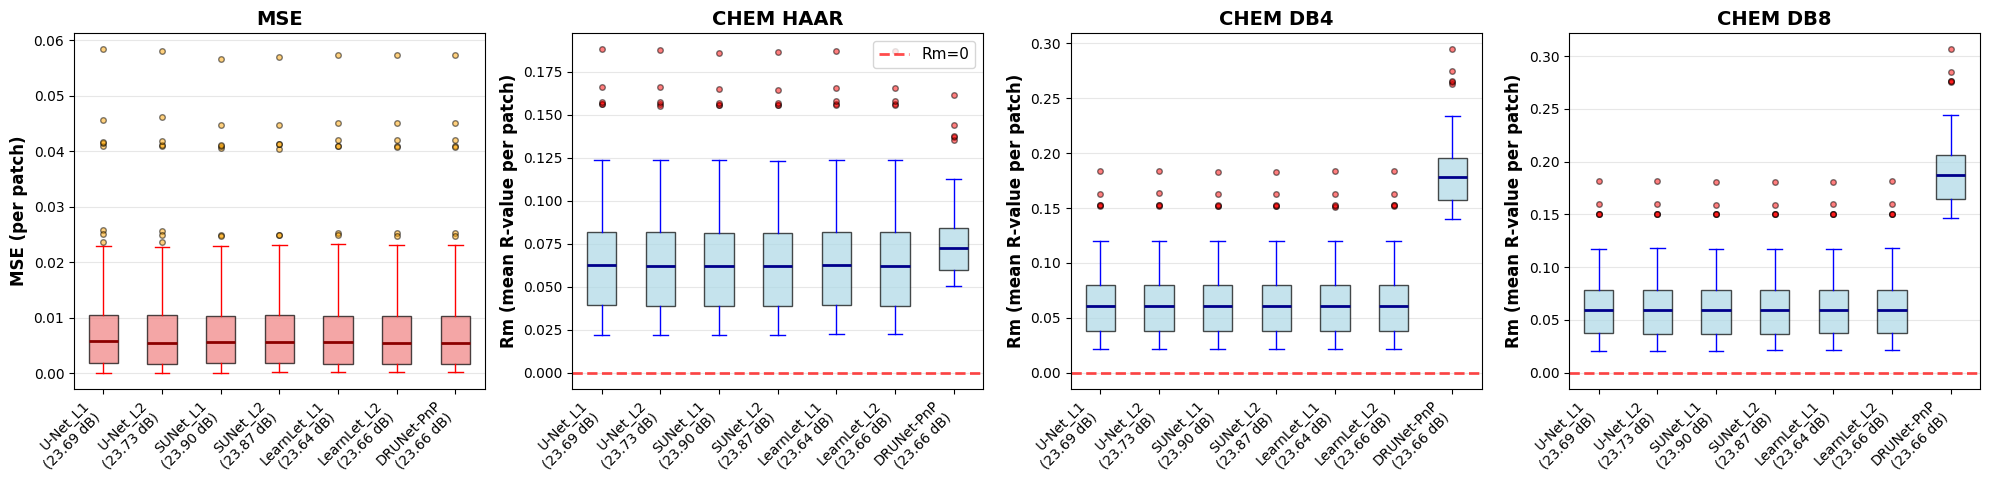

In [24]:
# Create box plots for Rm distributions and MSE distributions across wavelets
print("\n" + "="*100)
print("CREATING BOX PLOTS FOR Rm AND MSE DISTRIBUTIONS (Across validation set)")
print("="*100)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Column 0: MSE distribution
ax = axes[0]

# Prepare data for box plot - MSE values (one per patch) across validation set
mse_data = []
labels = []

for model_name in models.keys():
    # Collect MSE values across validation set (same for all wavelets)
    # Use any wavelet since MSE is the same across wavelets
    mse_vals = np.array(hi_results[model_name][wavelets[0]]['mse_list'])
    mse_data.append(mse_vals)
    
    # Add model name with average PSNR in brackets
    psnr_val = psnr_avg[model_name]
    labels.append(f"{model_name}\n({psnr_val:.2f} dB)")

# Create box plots with outliers shown
bp = ax.boxplot(mse_data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7),
                medianprops=dict(color='darkred', linewidth=2),
                whiskerprops=dict(color='red'),
                capprops=dict(color='red'),
                flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5),
                showfliers=True)  # Show outliers

# Rotate x-axis labels
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Set labels and title
ax.set_ylabel('MSE (per patch)', fontsize=12, fontweight='bold')
ax.set_title('MSE', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Columns 1-3: Rm distributions for each wavelet
for idx, wavelet in enumerate(wavelets):
    ax = axes[idx + 1]
    
    # Prepare data for box plot - Rm values (one per patch) across validation set
    rm_data = []
    labels = []
    
    for model_name in models.keys():
        # Collect Rm values (mean R per patch) across validation set
        rm_vals = np.array(hi_results[model_name][wavelet]['rm_list'])
        rm_data.append(rm_vals)
        
        # Add model name with average PSNR in brackets
        psnr_val = psnr_avg[model_name]
        labels.append(f"{model_name}\n({psnr_val:.2f} dB)")
    
    # Create box plots with outliers shown
    bp = ax.boxplot(rm_data, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='darkblue', linewidth=2),
                    whiskerprops=dict(color='blue'),
                    capprops=dict(color='blue'),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5),
                    showfliers=True)  # Show outliers
    
    # Rotate x-axis labels
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    
    # Set labels and title
    ax.set_ylabel('Rm (mean R-value per patch)', fontsize=12, fontweight='bold')
    ax.set_title(f'CHEM {wavelet.upper()}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add horizontal line at 0
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Rm=0')
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()

In [ ]:
## Spatial Maps


LEVEL-BASED DECOMPOSITION VISUALIZATION

Loading test image for level decomposition...

Decomposing prediction by frequency level:
  Model: U-Net_L1
  Wavelet: db8
  Image: test image 10

Number of decomposition levels: 3

Reconstructing individual levels:
  Level 1: coeff size (16, 16), reconstruction range [-0.176991, 0.275872], FINEST
  Level 2: coeff size (32, 32), reconstruction range [-0.059722, 0.170741], MEDIUM
  Level 3: coeff size (64, 64), reconstruction range [-0.085033, 0.097531], COARSEST


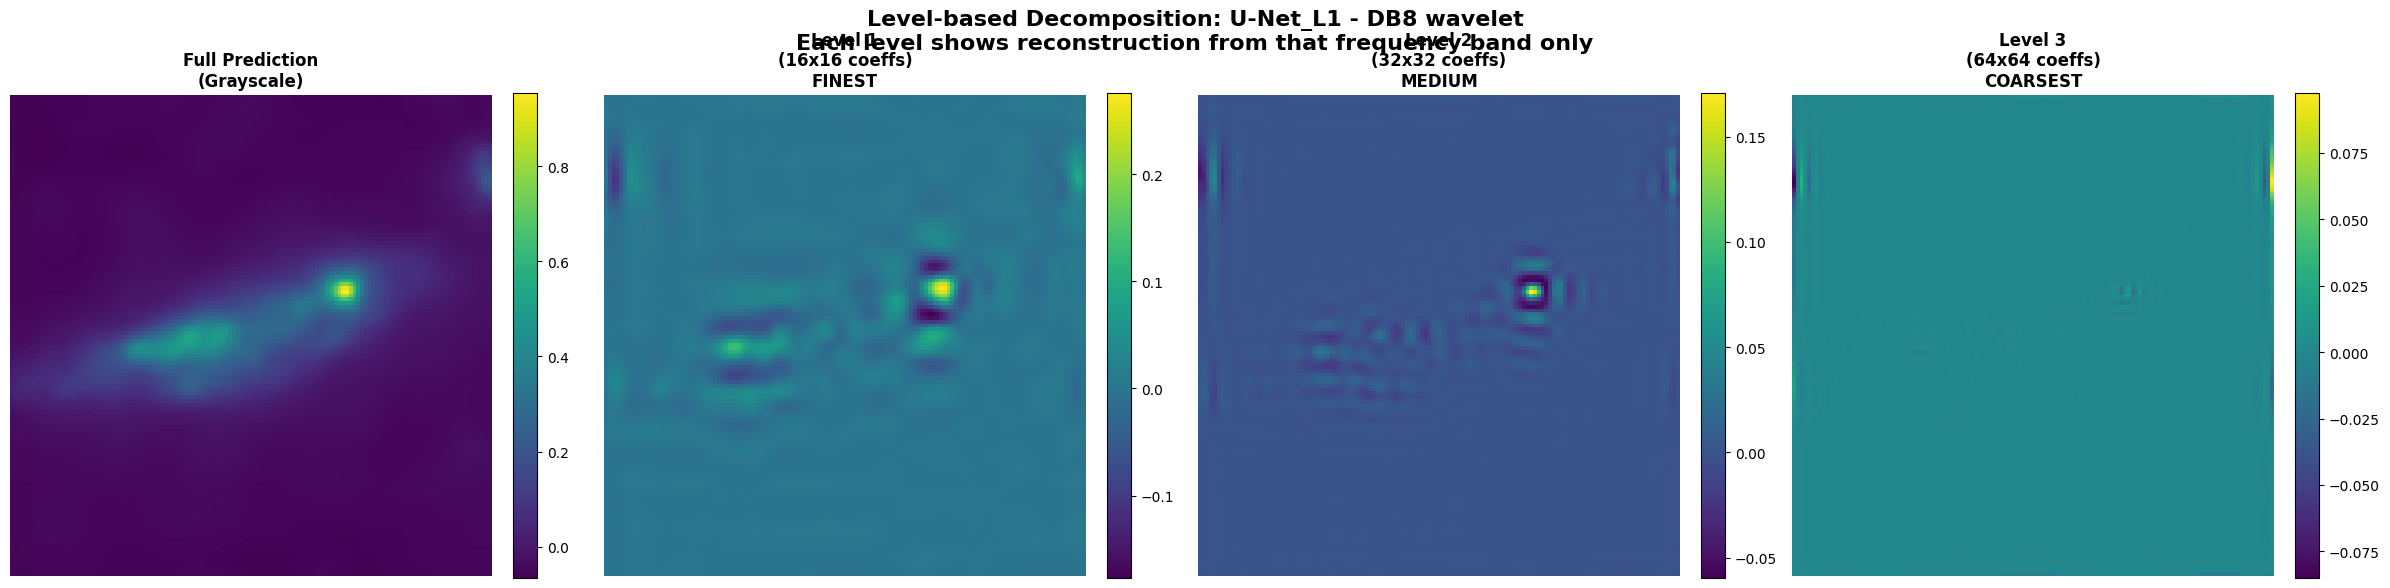

In [41]:
# Level-based Decomposition Visualization
print("\n" + "="*100)
print("LEVEL-BASED DECOMPOSITION VISUALIZATION")
print("="*100)

# Select a test image for visualization (grayscale CANDELS data)
print("\nLoading test image for level decomposition...")
vis_idx = 10  # Use test image 10
y_vis = test_inputs[vis_idx].to(device)  # Blurred input [1, 1, H, W]
x_vis = test_targets[vis_idx].to(device)  # Sharp target [1, 1, H, W]

# Pick first model and first wavelet for visualization
vis_model = list(models.keys())[0]  # First model
vis_wavelet = wavelets[2]  # db8

print(f"\nDecomposing prediction by frequency level:")
print(f"  Model: {vis_model}")
print(f"  Wavelet: {vis_wavelet}")
print(f"  Image: test image {vis_idx}")

# Generate prediction
with torch.no_grad():
    if vis_model == 'DRUNet-PnP':
        # DRUNet needs RGB conversion
        y_rgb = y_vis.repeat(1, 3, 1, 1)
        pred_rgb = models[vis_model](y_rgb, physics)
        pred_vis = pred_rgb.mean(dim=1, keepdim=True)  # Convert back to grayscale
    else:
        pred_vis = models[vis_model](y_vis)

# Extract grayscale image for decomposition [H, W]
pred_y = pred_vis[0, 0].cpu().numpy()
target_y = x_vis[0, 0].cpu().numpy()

# Helper function to reconstruct image from specific level
def reconstruct_single_level(img, level_idx, wavelet='db8', mode='periodization'):
    """
    Reconstruct image from a single wavelet level
    
    Args:
        img: 2D grayscale image
        level_idx: Which level to reconstruct (0=finest, increasing for coarser)
        wavelet: Wavelet type
        mode: Wavelet mode
        
    Returns:
        Reconstructed image from that level only
    """
    # Perform full decomposition
    coeffs = pywt.wavedec2(img, wavelet, mode=mode)
    
    # Create filtered coefficients - zero LL and all details except target level
    filtered_coeffs = []
    
    # Zero out LL coefficients (we only want detail from specific level)
    filtered_coeffs.append(np.zeros_like(coeffs[0]))
    
    # Zero out all detail levels except the target
    for detail_idx, (cH, cV, cD) in enumerate(coeffs[1:]):
        if detail_idx == level_idx:
            # Keep this level
            filtered_coeffs.append((cH, cV, cD))
        else:
            # Zero out this level
            filtered_coeffs.append((np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)))
    
    # Reconstruct
    recon = pywt.waverec2(filtered_coeffs, wavelet, mode=mode)
    return recon[:img.shape[0], :img.shape[1]]

# Compute wavelet decomposition
coeffs_2d = pywt.wavedec2(pred_y, vis_wavelet, mode='periodization')
coeffs_2d_detail = coeffs_2d[1:]
n_levels = len(coeffs_2d_detail)

print(f"\nNumber of decomposition levels: {n_levels}")

# Create figure: 1 row x (1 original + n_levels)
fig, axes = plt.subplots(1, n_levels + 1, figsize=(6*(n_levels+1), 6))

# Column 0: Original grayscale prediction
im0 = axes[0].imshow(pred_y, cmap='viridis')
axes[0].set_title(f'Full Prediction\n(Grayscale)', 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Columns 1+: Level reconstructions
print("\nReconstructing individual levels:")
for level_idx in range(n_levels):
    level_recon = reconstruct_single_level(pred_y, level_idx, vis_wavelet, 'periodization')
    
    # Get level coefficient shape
    cH, cV, cD = coeffs_2d_detail[level_idx]
    coeff_shape = cD.shape
    
    # Determine frequency label
    freq_label = 'FINEST' if level_idx == 0 else 'COARSEST' if level_idx == n_levels-1 else 'MEDIUM'
    
    im = axes[level_idx + 1].imshow(level_recon, cmap='viridis', vmin=level_recon.min(), vmax=level_recon.max())
    axes[level_idx + 1].set_title(f'Level {level_idx + 1}\n({coeff_shape[0]}x{coeff_shape[1]} coeffs)\n{freq_label}', 
                                  fontsize=12, fontweight='bold')
    axes[level_idx + 1].axis('off')
    plt.colorbar(im, ax=axes[level_idx + 1], fraction=0.046, pad=0.04)
    
    print(f"  Level {level_idx + 1}: coeff size {coeff_shape}, "
          f"reconstruction range [{level_recon.min():.6f}, {level_recon.max():.6f}], {freq_label}")

plt.suptitle(f'Level-based Decomposition: {vis_model} - {vis_wavelet.upper()} wavelet\n'
             f'Each level shows reconstruction from that frequency band only',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


LEVEL-WISE SPATIAL VISUALIZATION (GRAYSCALE)

Creating comprehensive spatial analysis for:
  Model: U-Net_L1
  Wavelet: db8
  Image: test image 10

Creating full spatial R-value map...
  R-value map shape: (128, 128)
  R-value map range: [-6.617954, 6.298141]

Creating level-wise spatial maps...
  Level 1:
    MSE map range: [-0.074752, 0.115027]
    R-value map range: [-2.709756, 4.327401]
  Level 2:
    MSE map range: [-0.105801, 0.086088]
    R-value map range: [-4.298041, 3.738941]
  Level 3:
    MSE map range: [-0.012339, 0.011314]
    R-value map range: [-3.185476, 2.492003]


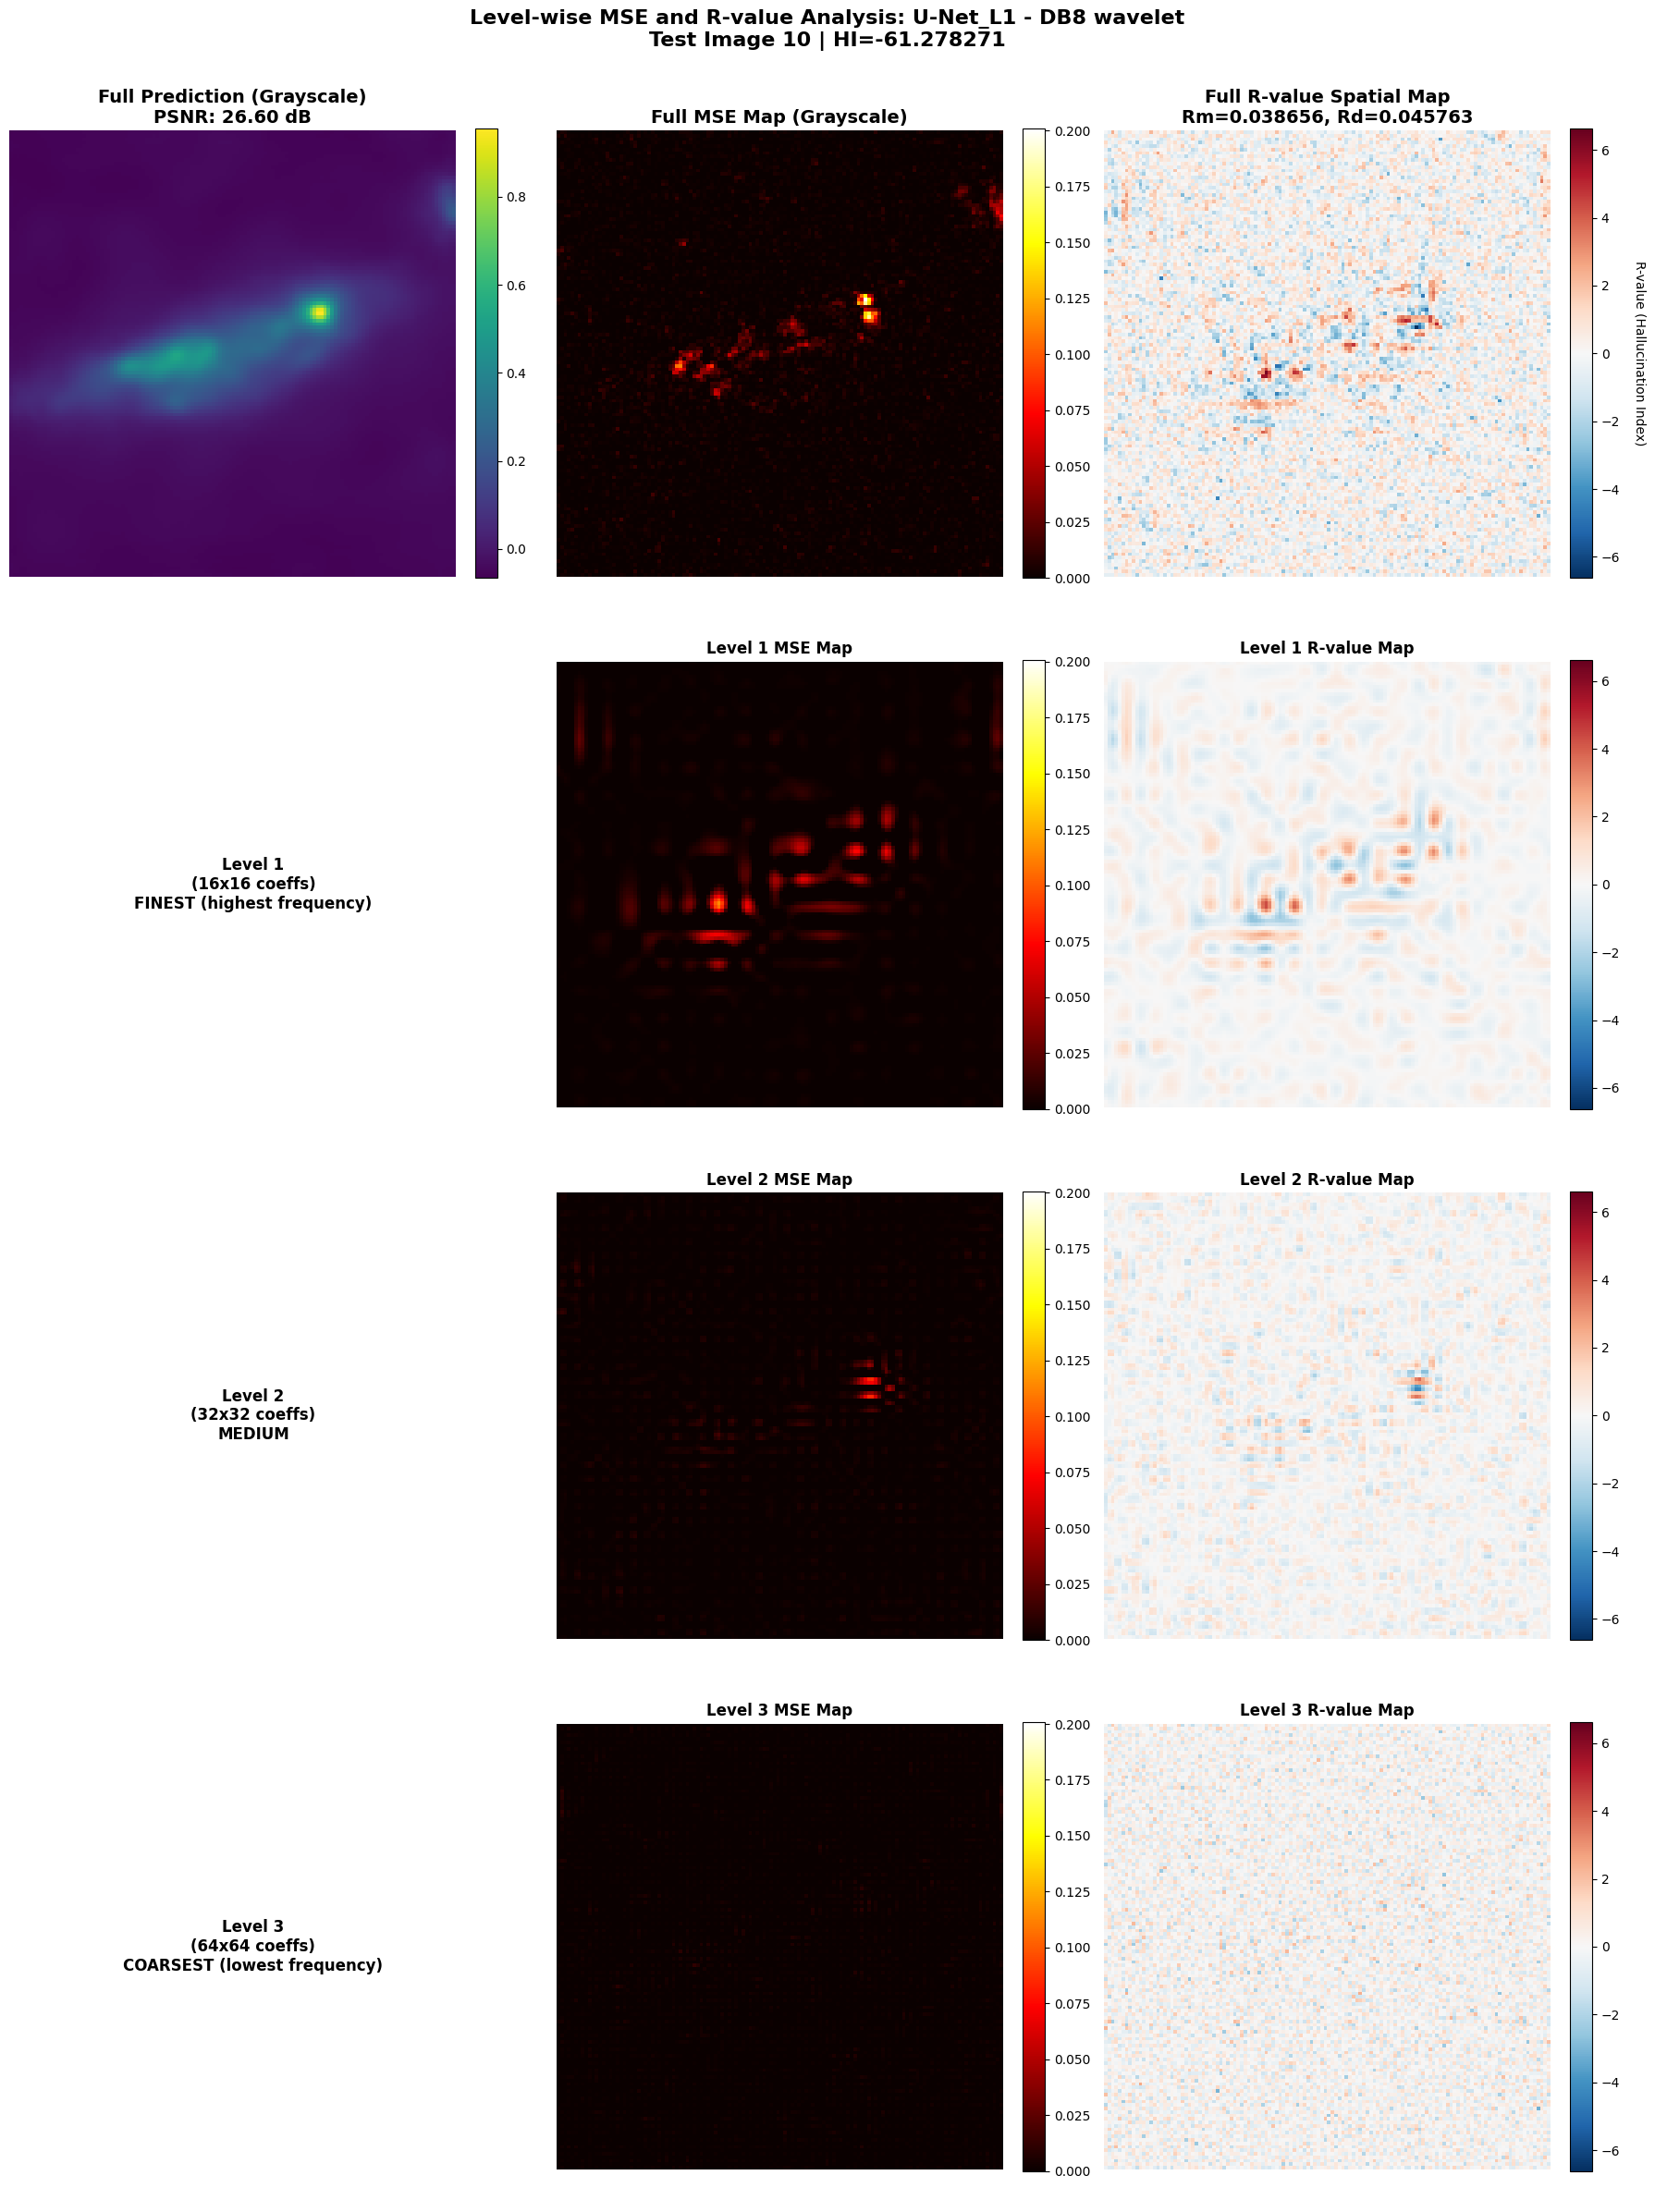


Level-wise spatial map analysis complete!


In [ ]:
# Level-wise Spatial Visualization (Grayscale version with comprehensive maps)
print("\n" + "="*100)
print("LEVEL-WISE SPATIAL VISUALIZATION (GRAYSCALE)")
print("="*100)

print(f"\nCreating comprehensive spatial analysis for:")
print(f"  Model: {vis_model}")
print(f"  Wavelet: {vis_wavelet}")
print(f"  Image: test image {vis_idx}")

# Compute chem on grayscale image (for R-values)
Hmeasure = Wavelet_Hallucination_Index(alpha, theta, vis_wavelet)
Hmeasure.to(device)
Hmeasure.eval()

# Use the confidence interval radius for this model
if vis_model in confidence_intervals:
    interval_radius_vis = confidence_intervals[vis_model]
else:
    # Use a default value if not computed
    interval_radius_vis = np.ones((x_vis.shape[2], x_vis.shape[3])) * 0.05

# Ensure correct shape for interval radius
if interval_radius_vis.ndim == 0:  # Scalar
    interval_radius_vis = np.ones((x_vis.shape[2], x_vis.shape[3])) * interval_radius_vis
elif interval_radius_vis.shape != (x_vis.shape[2], x_vis.shape[3]):
    # Resize if needed
    interval_radius_vis = np.ones((x_vis.shape[2], x_vis.shape[3])) * interval_radius_vis.mean()

interval_radius_tensor = torch.tensor(interval_radius_vis, dtype=torch.float32).to(device)

with torch.no_grad():
    hi, R, rm, rd = Hmeasure(x_vis, pred_vis, interval_radius_tensor, debug=False)

# Extract grayscale image (already grayscale, no need for Y-channel extraction)
R_values_flat = R[0, 0, :].cpu().numpy()

# Build band_info (order: HL, LH, HH, matching image_to_wavelet_coeffs)
band_info = []
flat_idx = 0

for level_idx, (cH, cV, cD) in enumerate(coeffs_2d_detail):
    level_info = {
        'level': level_idx,
        'HL': {'shape': cH.shape, 'start_idx': flat_idx, 'end_idx': flat_idx + cH.size},
        'LH': {'shape': cV.shape, 'start_idx': flat_idx + cH.size, 'end_idx': flat_idx + cH.size + cV.size},
        'HH': {'shape': cD.shape, 'start_idx': flat_idx + cH.size + cV.size, 'end_idx': flat_idx + cD.size + cH.size + cV.size}
    }
    flat_idx += cD.size + cH.size + cV.size
    band_info.append(level_info)

# Helper function to create full spatial R-value map
def create_r_value_spatial_map(R_values_flat, band_info, target_shape, wavelet='db8'):
    """Create a 2D spatial map of R-values by reconstructing from coefficients"""
    r_coeffs = []
    
    # LL coefficients - zero since they're not in our R-values
    first_detail_size = band_info[0]['HH']['shape'][0]
    r_coeffs.append(np.zeros((first_detail_size, first_detail_size)))
    
    # Fill detail coefficients with R-values (in PyWavelets order: cH, cV, cD = HL, LH, HH)
    for level_info in band_info:
        hl_r = R_values_flat[level_info['HL']['start_idx']:level_info['HL']['end_idx']].reshape(level_info['HL']['shape'])
        lh_r = R_values_flat[level_info['LH']['start_idx']:level_info['LH']['end_idx']].reshape(level_info['LH']['shape'])
        hh_r = R_values_flat[level_info['HH']['start_idx']:level_info['HH']['end_idx']].reshape(level_info['HH']['shape'])
        
        r_coeffs.append((hl_r, lh_r, hh_r))  # pywt uses (cH, cV, cD) order
    
    # Reconstruct to get spatial R-value map
    r_map = pywt.waverec2(r_coeffs, wavelet, mode='periodization')
    r_map = r_map[:target_shape[0], :target_shape[1]]
    
    return r_map

# Helper function to create spatial maps for a specific level
def create_level_spatial_maps(prediction_y, target_y, R_values_flat, level_idx, band_info, wavelet='db8'):
    """Create MSE and R-value spatial maps for a specific wavelet level"""
    # Compute wavelet coefficients for prediction and target
    pred_coeffs = pywt.wavedec2(prediction_y, wavelet, mode='periodization')
    target_coeffs = pywt.wavedec2(target_y, wavelet, mode='periodization')
    
    # Create MSE map from coefficients at this level
    mse_coeffs = []
    mse_coeffs.append(np.zeros_like(pred_coeffs[0]))  # Zero LL
    
    for detail_idx, ((cH_p, cV_p, cD_p), (cH_t, cV_t, cD_t)) in enumerate(zip(pred_coeffs[1:], target_coeffs[1:])):
        if detail_idx == level_idx:
            # Compute MSE for this level
            mse_cH = (cH_p - cH_t) ** 2
            mse_cV = (cV_p - cV_t) ** 2
            mse_cD = (cD_p - cD_t) ** 2
            mse_coeffs.append((mse_cH, mse_cV, mse_cD))
        else:
            # Zero out other levels
            mse_coeffs.append((np.zeros_like(cH_p), np.zeros_like(cV_p), np.zeros_like(cD_p)))
    
    # Reconstruct MSE map
    mse_map = pywt.waverec2(mse_coeffs, wavelet, mode='periodization')
    mse_map = mse_map[:prediction_y.shape[0], :prediction_y.shape[1]]
    
    # Create R-value map from coefficients at this level
    r_coeffs = []
    
    # Zero LL
    first_detail_size = band_info[0]['HH']['shape'][0]
    r_coeffs.append(np.zeros((first_detail_size, first_detail_size)))
    
    # Fill only the target level with R-values
    for level_idx_iter, level_info_iter in enumerate(band_info):
        if level_idx_iter == level_idx:
            hl_r = R_values_flat[level_info_iter['HL']['start_idx']:level_info_iter['HL']['end_idx']].reshape(level_info_iter['HL']['shape'])
            lh_r = R_values_flat[level_info_iter['LH']['start_idx']:level_info_iter['LH']['end_idx']].reshape(level_info_iter['LH']['shape'])
            hh_r = R_values_flat[level_info_iter['HH']['start_idx']:level_info_iter['HH']['end_idx']].reshape(level_info_iter['HH']['shape'])
            
            r_coeffs.append((hl_r, lh_r, hh_r))
        else:
            dummy_shape = level_info_iter['HH']['shape']
            r_coeffs.append((np.zeros(dummy_shape), np.zeros(dummy_shape), np.zeros(dummy_shape)))
    
    # Reconstruct R-value map
    r_map = pywt.waverec2(r_coeffs, wavelet, mode='periodization')
    r_map = r_map[:prediction_y.shape[0], :prediction_y.shape[1]]
    
    return mse_map, r_map

# Compute full MSE map (Y-channel)
mse_map_full = (pred_y - target_y) ** 2

# Create full spatial R-value map
print("\nCreating full spatial R-value map...")
r_value_map_full = create_r_value_spatial_map(R_values_flat, band_info, pred_y.shape, vis_wavelet)
print(f"  R-value map shape: {r_value_map_full.shape}")
print(f"  R-value map range: [{r_value_map_full.min():.6f}, {r_value_map_full.max():.6f}]")

# Compute PSNR for display
psnr_val = dinv.metric.PSNR()(pred_vis, x_vis).item()

# Create figure: (n_levels + 1) rows x 3 columns
fig, axes = plt.subplots(n_levels + 1, 3, figsize=(18, 6*(n_levels + 1)))

# ROW 0: Full RGB prediction, full MSE, full R-value map
# Column 0: Full Prediction (RGB)
im00 = axes[0, 0].imshow(pred_y, cmap='viridis')
axes[0, 0].set_title(f'Full Prediction (Grayscale)\nPSNR: {psnr_val:.2f} dB', 
                     fontsize=14, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

# Column 1: Full MSE map (Y-channel)
im01 = axes[0, 1].imshow(mse_map_full, cmap='hot', vmin=0, vmax=mse_map_full.max())
axes[0, 1].set_title(f'Full MSE Map (Grayscale)', 
                     fontsize=14, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Column 2: Full R-value map
vmax_r_full = max(abs(r_value_map_full.min()), abs(r_value_map_full.max()))
im02 = axes[0, 2].imshow(r_value_map_full, cmap='RdBu_r', vmin=-vmax_r_full, vmax=vmax_r_full)
axes[0, 2].set_title(f'Full R-value Spatial Map\nRm={rm.item():.6f}, Rd={rd.item():.6f}', 
                     fontsize=14, fontweight='bold')
axes[0, 2].axis('off')
cbar02 = plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)
cbar02.set_label('R-value (CHEM)', rotation=270, labelpad=20)

# ROWS 1+: Level-wise breakdown
print("\nCreating level-wise spatial maps...")

for level_idx in range(n_levels):
    row_idx = level_idx + 1  # Offset by 1 because row 0 is full maps
    level_info = band_info[level_idx]
    
    # Column 0: Level info text
    axes[row_idx, 0].axis('off')
    freq_label = 'FINEST (highest frequency)' if level_idx == 0 else 'COARSEST (lowest frequency)' if level_idx == n_levels-1 else 'MEDIUM'
    axes[row_idx, 0].text(0.5, 0.5, f'Level {level_idx + 1}\n({level_info["HH"]["shape"][0]}x{level_info["HH"]["shape"][1]} coeffs)\n{freq_label}', 
                          ha='center', va='center', transform=axes[row_idx, 0].transAxes,
                          fontsize=12, fontweight='bold')
    
    # Create spatial maps for this level
    mse_map_level, r_map_level = create_level_spatial_maps(
        pred_y, target_y, R_values_flat, level_idx, band_info, vis_wavelet
    )
    
    print(f"  Level {level_idx + 1}:")
    print(f"    MSE map range: [{mse_map_level.min():.6f}, {mse_map_level.max():.6f}]")
    print(f"    R-value map range: [{r_map_level.min():.6f}, {r_map_level.max():.6f}]")
    
    # Column 1: MSE map for this level
    im1 = axes[row_idx, 1].imshow(mse_map_level, cmap='hot', vmin=0, vmax=mse_map_full.max())
    axes[row_idx, 1].set_title(f'Level {level_idx + 1} MSE Map', 
                                fontsize=12, fontweight='bold')
    axes[row_idx, 1].axis('off')
    plt.colorbar(im1, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)
    
    # Column 2: R-value map for this level
    if vmax_r_full > 1e-10:
        im2 = axes[row_idx, 2].imshow(r_map_level, cmap='RdBu_r', vmin=-vmax_r_full, vmax=vmax_r_full)
    else:
        im2 = axes[row_idx, 2].imshow(r_map_level, cmap='gray')
    
    axes[row_idx, 2].set_title(f'Level {level_idx + 1} R-value Map', 
                                fontsize=12, fontweight='bold')
    axes[row_idx, 2].axis('off')
    plt.colorbar(im2, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

plt.suptitle(f'Level-wise MSE and R-value Analysis: {vis_model} - {vis_wavelet.upper()} wavelet\n'
             f'Test Image {vis_idx} | HI={hi.item():.6f}',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\nLevel-wise spatial map analysis complete!")

In [ ]:
### Highest Hallucination in Level n and n-1 spatial map



COMBINED COARSEST TWO LEVELS ANALYSIS: HIGHLIGHTING HIGH CHEM VALUES

Calculating global threshold across both levels...
Global R-value statistics for both levels:
  Mean: -0.044586
  Std:  0.890935
  Global Threshold (mean + std): 1.737283
  Min:  -0.844688
  Max:  13.068038

--------------------------------------------------------------------------------
Processing Second-Coarsest Level (Level 2):
  Coefficient shape: (32, 32)
  Coefficients above global threshold: 325 (10.6%)

--------------------------------------------------------------------------------
Processing Coarsest Level (Level 3):
  Coefficient shape: (64, 64)
  Coefficients above global threshold: 362 (2.9%)

--------------------------------------------------------------------------------
Combining maps...
  Target shape (from Level 2): (128, 128)
  Upsampling Level 3 by factors: (1.0, 1.0)
  Combined maps created!


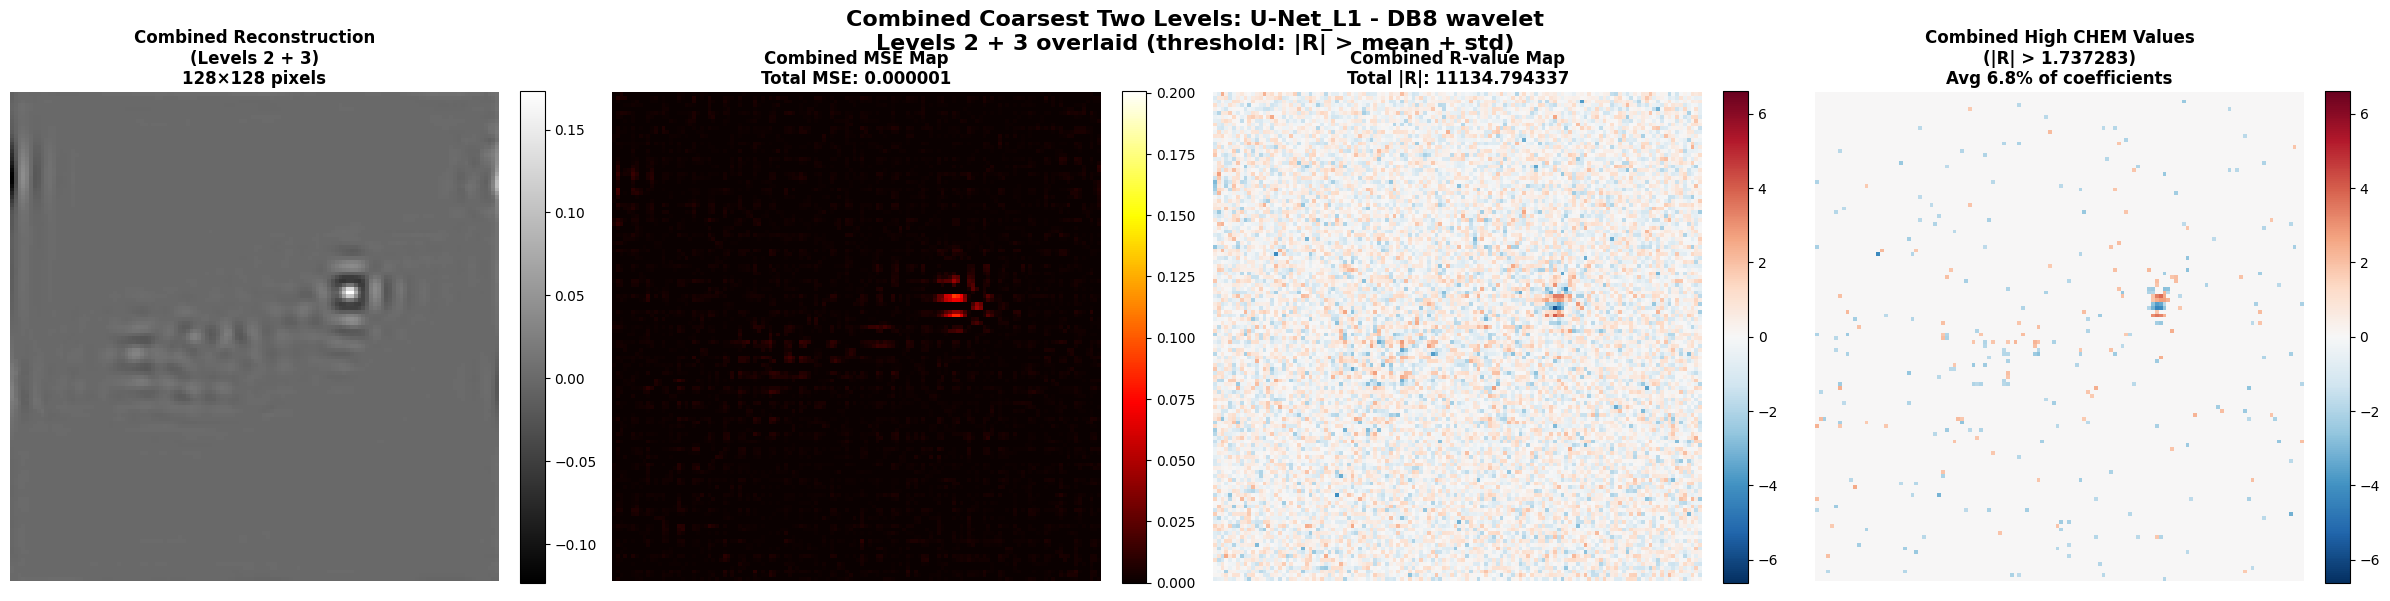


Combined coarsest two levels analysis complete!


In [ ]:
# Focused Analysis: Combining High CHEM Values from finest Two Levels
print("\n" + "="*100)
print("COMBINED FINEST TWO LEVELS ANALYSIS: HIGHLIGHTING HIGH CHEM VALUES")
print("="*100)

# Identify the finest two levels
finest_level_idx = n_levels - 1
second_finest_level_idx = n_levels - 2

levels_to_analyze = [
    (second_finest_level_idx, "Second-Finest"),
    (finest_level_idx, "Finest")
]

# Calculate global threshold across both levels
print("\nCalculating global threshold across both levels...")
all_r_both_levels = []
for level_idx, _ in levels_to_analyze:
    level_info = band_info[level_idx]
    hl_r = R_values_flat[level_info['HL']['start_idx']:level_info['HL']['end_idx']].reshape(level_info['HL']['shape'])
    lh_r = R_values_flat[level_info['LH']['start_idx']:level_info['LH']['end_idx']].reshape(level_info['LH']['shape'])
    hh_r = R_values_flat[level_info['HH']['start_idx']:level_info['HH']['end_idx']].reshape(level_info['HH']['shape'])
    all_r_both_levels.extend([hl_r.flatten(), lh_r.flatten(), hh_r.flatten()])

all_r_both_levels = np.concatenate(all_r_both_levels)
global_threshold = all_r_both_levels.mean() + 2* all_r_both_levels.std()

print(f"Global R-value statistics for both levels:")
print(f"  Mean: {all_r_both_levels.mean():.6f}")
print(f"  Std:  {all_r_both_levels.std():.6f}")
print(f"  Global Threshold (mean + std): {global_threshold:.6f}")
print(f"  Min:  {all_r_both_levels.min():.6f}")
print(f"  Max:  {all_r_both_levels.max():.6f}")

# Create spatial maps for both levels
maps_by_level = {}
for level_idx, level_name in levels_to_analyze:
    level_info = band_info[level_idx]
    
    print(f"\n{'-'*80}")
    print(f"Processing {level_name} Level (Level {level_idx + 1}):")
    print(f"  Coefficient shape: {level_info['HH']['shape']}")
    
    # Extract R-values for this level
    hl_r = R_values_flat[level_info['HL']['start_idx']:level_info['HL']['end_idx']].reshape(level_info['HL']['shape'])
    lh_r = R_values_flat[level_info['LH']['start_idx']:level_info['LH']['end_idx']].reshape(level_info['LH']['shape'])
    hh_r = R_values_flat[level_info['HH']['start_idx']:level_info['HH']['end_idx']].reshape(level_info['HH']['shape'])
    
    all_r_level = np.concatenate([hl_r.flatten(), lh_r.flatten(), hh_r.flatten()])
    
    # Count values above threshold
    n_above_threshold = np.sum(np.abs(all_r_level) > global_threshold)
    pct_above_threshold = n_above_threshold / len(all_r_level) * 100
    print(f"  Coefficients above global threshold: {n_above_threshold} ({pct_above_threshold:.1f}%)")
    
    # Create spatial maps
    mse_map_level, r_map_level = create_level_spatial_maps(
        pred_y, target_y, R_values_flat, level_idx, band_info, vis_wavelet
    )
    
    # Get level reconstruction
    level_recon = reconstruct_single_level(pred_y, level_idx, vis_wavelet, 'periodization')
    
    # Create highlight mask for high CHEM values
    highlight_mask = np.abs(r_map_level) > global_threshold
    r_map_highlighted = np.copy(r_map_level)
    r_map_highlighted[~highlight_mask] = 0  # Zero out values below threshold
    
    # Store maps
    maps_by_level[level_idx] = {
        'recon': level_recon,
        'mse': mse_map_level,
        'r_map': r_map_level,
        'r_highlighted': r_map_highlighted,
        'pct_above': pct_above_threshold
    }

# Combine the maps 
from scipy.ndimage import zoom

print(f"\n{'-'*80}")
print("Combining maps...")

# Get the target shape from second-finest level
target_shape = maps_by_level[second_finest_level_idx]['recon'].shape
print(f"  Target shape (from Level {second_finest_level_idx + 1}): {target_shape}")

# Upsample finest level maps to match second-finest level
finest_shape = maps_by_level[finest_level_idx]['recon'].shape
zoom_factors = (target_shape[0] / finest_shape[0], target_shape[1] / finest_shape[1])
print(f"  Upsampling Level {finest_level_idx + 1} by factors: {zoom_factors}")

finest_recon_up = zoom(maps_by_level[finest_level_idx]['recon'], zoom_factors, order=1)
finest_mse_up = zoom(maps_by_level[finest_level_idx]['mse'], zoom_factors, order=1)
finest_r_up = zoom(maps_by_level[finest_level_idx]['r_map'], zoom_factors, order=1)
finest_r_highlighted_up = zoom(maps_by_level[finest_level_idx]['r_highlighted'], zoom_factors, order=1)

# Combine maps by addition
combined_recon = maps_by_level[second_finest_level_idx]['recon'] + finest_recon_up
combined_mse = maps_by_level[second_finest_level_idx]['mse'] + finest_mse_up
combined_r = maps_by_level[second_finest_level_idx]['r_map'] + finest_r_up
combined_r_highlighted = maps_by_level[second_finest_level_idx]['r_highlighted'] + finest_r_highlighted_up

# Calculate combined statistics
combined_pct_above = (maps_by_level[second_finest_level_idx]['pct_above'] + 
                      maps_by_level[finest_level_idx]['pct_above']) / 2

print(f"  Combined maps created!")

# Create figure with combined maps
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Column 0: Combined reconstruction
im0 = axes[0].imshow(combined_recon, cmap='viridis')
axes[0].set_title(f'Combined Reconstruction\n(Levels {second_finest_level_idx + 1} + {finest_level_idx + 1})\n{target_shape[0]}×{target_shape[1]} pixels', 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Column 1: Combined MSE map
im1 = axes[1].imshow(combined_mse, cmap='hot', vmin=0, vmax=mse_map_full.max())
axes[1].set_title(f'Combined MSE Map\nTotal MSE: {combined_mse.sum():.6f}', 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Column 2: Combined R-value map
if vmax_r_full > 1e-10:
    im2 = axes[2].imshow(combined_r, cmap='RdBu_r', vmin=-vmax_r_full, vmax=vmax_r_full)
else:
    im2 = axes[2].imshow(combined_r, cmap='viridis')

axes[2].set_title(f'Combined R-value Map\nTotal |R|: {np.abs(combined_r).sum():.6f}', 
                  fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Column 3: Combined highlighted high CHEM values
if vmax_r_full > 1e-10:
    im3 = axes[3].imshow(combined_r_highlighted, cmap='RdBu_r', vmin=-vmax_r_full, vmax=vmax_r_full)
else:
    im3 = axes[3].imshow(combined_r_highlighted, cmap='viridis')

axes[3].set_title(f'Combined High CHEM Values\n(|R| > {global_threshold:.6f})\nAvg {combined_pct_above:.1f}% of coefficients', 
                  fontsize=12, fontweight='bold')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle(f'Combined Coarsest Two Levels: {vis_model} - {vis_wavelet.upper()} wavelet\n'
             f'Levels {second_finest_level_idx + 1} + {finest_level_idx + 1} overlaid (threshold: |R| > mean + std)',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("Combined finest two levels analysis complete!")
print("="*100)

# Clear GPU memory
if 'x_vis' in locals():
    del x_vis, y_vis, pred_vis
torch.cuda.empty_cache()